In [14]:
!pip install psycopg2-binary
!pip install pandas_ta
!pip install imblearn

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [35]:
import keras.backend as K
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas_ta as ta
import plotly
import plotly.graph_objs as go
import plotly.express as px
import tensorflow as tf

from datetime import datetime,timedelta
from imblearn.over_sampling import SMOTE
from keras.layers import Input,Reshape, Conv1D, Flatten, MaxPooling1D,BatchNormalization,Dense
from plotly.subplots import make_subplots
from sklearn.model_selection import  train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sqlalchemy import create_engine, text
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [16]:
#Размеченный датасет с точками 
df=pd.read_csv('df_imp_1.csv',sep=',')
df=df.drop(columns=['Unnamed: 0'])

In [17]:
#Окончание 30 11 20224
df = df.rename(columns={'price_kategory_trade':'imp_class'})
df=df[df['timestamp']<='2024-11-30 23:00:00']

In [18]:
# Окончание обучения октябрь
df_orign = df.copy()
df=df.replace(-3,-1)
df=df.replace(3,1)
df_tail = df[df['timestamp']>='2024-11-01 00:00:00']
df = df[df['timestamp']<'2024-11-01 00:00:00']

In [19]:
# Визуализация разметки
trade_start_up1 = df_orign[['timestamp','close']][df_orign['imp_class']==1]
trade_stop_up1 = df_orign[['timestamp','close']][df_orign['imp_class']==2]
trade_start_down1 = df_orign[['timestamp','close']][df_orign['imp_class']==-1]
trade_stop_down1 = df_orign[['timestamp','close']][df_orign['imp_class']==-2]
trade_3 = df_orign[['timestamp','close']][df_orign['imp_class']==2]
trade_m3 = df_orign[['timestamp','close']][df_orign['imp_class']==-3]

In [20]:
fig = make_subplots(rows=1, cols=1)
fig.add_trace(go.Scatter(x=df_orign.timestamp, y=df_orign.close, name='close',line_color = 'black', line_width=2 ))
fig.add_trace(go.Scatter(x=trade_stop_up1.timestamp, y=trade_stop_up1.close, name='stop_up',line_color = 'purple', line_width=1, mode='markers', marker_size = 8, marker_symbol = 2 ))
fig.add_trace(go.Scatter(x=trade_start_up1.timestamp, y=trade_start_up1.close, name='start_up',line_color = 'green', line_width=1, mode='markers', marker_size = 8, marker_symbol = 5 ))
fig.add_trace(go.Scatter(x=trade_stop_down1.timestamp, y=trade_stop_down1.close, name='stop_down',line_color = 'blue', line_width=1, mode='markers', marker_size = 8, marker_symbol = 1 ))
fig.add_trace(go.Scatter(x=trade_start_down1.timestamp, y=trade_start_down1.close, name='start_down',line_color = 'red', line_width=1, mode='markers', marker_size = 8, marker_symbol = 6 ))

#fig.add_trace(go.Scatter(x=trade_3.timestamp, y=trade_3.close, name='stop_down',line_color = 'gray', line_width=1, mode='markers', marker_size = 5, marker_symbol = 5 ))
#fig.add_trace(go.Scatter(x=trade_m3.timestamp, y=trade_m3.close, name='start_down',line_color = 'gray', line_width=1, mode='markers', marker_size = 10, marker_symbol = 6))


fig.update_layout(hovermode="x", title = "Цена и начало/конец импульса")

In [21]:
X = df.drop(columns=['timestamp','imp_class'])
y = df['imp_class']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) 
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [30]:
#Балансировка классов
X_train_initial,X_test,y_train_initial,y_test = train_test_split(X_scaled,y_encoded,test_size=0.2,random_state=42,stratify=y)
smote = SMOTE(random_state=42)
X_train,y_train = smote.fit_resample(X_train_initial,y_train_initial)

In [31]:
# Автоэнкодер с классификатором
input_dim = X_train.shape[1]
encoding_dim = 4 # размерность латентного пространства
# Входной слой
input_layer = Input(shape=(input_dim,))
reshaped_input = Reshape((input_dim, 1))(input_layer) 
# Сверточные слои
conv1 = Conv1D(32, kernel_size=3, activation='relu', padding='same')(reshaped_input)
conv1 = MaxPooling1D(pool_size=2)(conv1)
encoder = BatchNormalization()(conv1)
conv2 = Conv1D(64, kernel_size=3, activation='relu', padding='same')(encoder)
conv2 = MaxPooling1D(pool_size=2)(conv2)
encoder = BatchNormalization()(conv2)
flattened = Flatten()(encoder)
decoder = Dense(128, activation='relu')(flattened) 
# Кодировочная часть после сверток
encoder = BatchNormalization()(decoder)
latent_space = Dense(encoding_dim, activation='relu', name='latent_space')(encoder)
decoder = Dense(128, activation='relu')(latent_space)
decoder = Dense(512, activation='relu')(decoder)
decoder = BatchNormalization()(decoder)
decoder = Reshape((128, 4))(decoder)
# Пвосстанавливаем размерность
decoder = Conv1D(32, kernel_size=3, activation='relu', padding='same')(decoder)
decoder = Flatten()(decoder)
reconstructed_output = Dense(input_dim, activation='linear', name='reconstructed_output')(decoder)
# Классификатор
classification_output = Dense(5, activation='softmax', name='class_output')(latent_space)
autoencoder_classifier = Model(inputs=input_layer,outputs=[reconstructed_output,classification_output])

In [60]:
# Что бы снизить зависимость от класса 0 (2 в labelencoder)
y_train_mapped = y_train.copy()
y_train_mapped[y_train == 2] = -1
# Вводим фиктивный класс (например, -1)
# Модификация функции потерь
def custom_loss(y_true, y_pred):
    # Применяем маску к y_true, чтобы исключить значения -1
    mask = K.not_equal(y_true, -1)
    # Преобразуем булевую маску в индексы TensorFlow
    indices = tf.where(mask)
    # Используем индексы, чтобы выбрать элементы из y_true и y_pred
    y_true_masked = tf.gather(y_true, indices)
    y_pred_masked = tf.gather(y_pred, indices)
    # Используем sparse_categorical_crossentropy с маской
    return K.sparse_categorical_crossentropy(y_true_masked, y_pred_masked)

optimizer=Adam(learning_rate=0.000039)
autoencoder_classifier.compile( optimizer=optimizer, loss={'reconstructed_output': 'mse', 'class_output': custom_loss},
                               loss_weights= {'reconstructed_output':0.5 ,'class_output':0.5},
                               metrics={'class_output': 'accuracy'} )

In [61]:
history = autoencoder_classifier.fit( X_train, {'reconstructed_output': X_train, 'class_output': y_train},
                                     epochs=10, batch_size=32, 
                                     validation_data=(X_test, {'reconstructed_output': X_test, 'class_output': y_test}),
                                     verbose=1 )

Epoch 1/10
3940/3940 [==============================] - 24s 6ms/step - loss: 0.2411 - reconstructed_output_loss: 0.2184 - class_output_loss: 0.2639 - class_output_accuracy: 0.9110 - val_loss: 0.4753 - val_reconstructed_output_loss: 0.2381 - val_class_output_loss: 0.7125 - val_class_output_accuracy: 0.7968
Epoch 2/10
3940/3940 [==============================] - 23s 6ms/step - loss: 0.2394 - reconstructed_output_loss: 0.2177 - class_output_loss: 0.2611 - class_output_accuracy: 0.9127 - val_loss: 0.4563 - val_reconstructed_output_loss: 0.2382 - val_class_output_loss: 0.6744 - val_class_output_accuracy: 0.8066
Epoch 3/10
3940/3940 [==============================] - 23s 6ms/step - loss: 0.2366 - reconstructed_output_loss: 0.2177 - class_output_loss: 0.2556 - class_output_accuracy: 0.9130 - val_loss: 0.4685 - val_reconstructed_output_loss: 0.2384 - val_class_output_loss: 0.6986 - val_class_output_accuracy: 0.7990
Epoch 4/10
3940/3940 [==============================] - 23s 6ms/step - loss: 0.

In [44]:
model_path = f"data_dots_type_1h_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"
autoencoder_classifier.save(model_path)

INFO:tensorflow:Assets written to: data_dots_type_1h_2024-12-19_14-31-22/assets


INFO:tensorflow:Assets written to: data_dots_type_1h_2024-12-19_14-31-22/assets


In [ ]:
# # Извлечение модели-энкодера для латентного пространства
# encoder_model = Model(inputs=input_layer, outputs=latent_space)
# latent_representations = encoder_model.predict(X_test)

# # Визуализация
# import seaborn as sns

# sns.scatterplot(x=latent_representations[:, 0], y=latent_representations[:, 1], hue=np.argmax(y_test, axis=1))
# plt.title('Latent Space Visualization')
# plt.xlabel('Latent Dimension 1')
# plt.ylabel('Latent Dimension 2')
# plt.show()

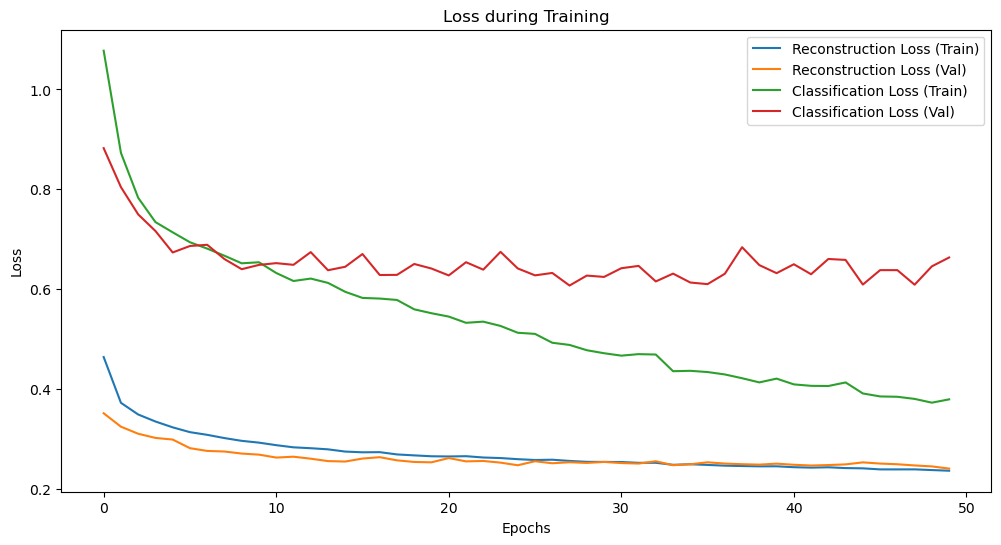

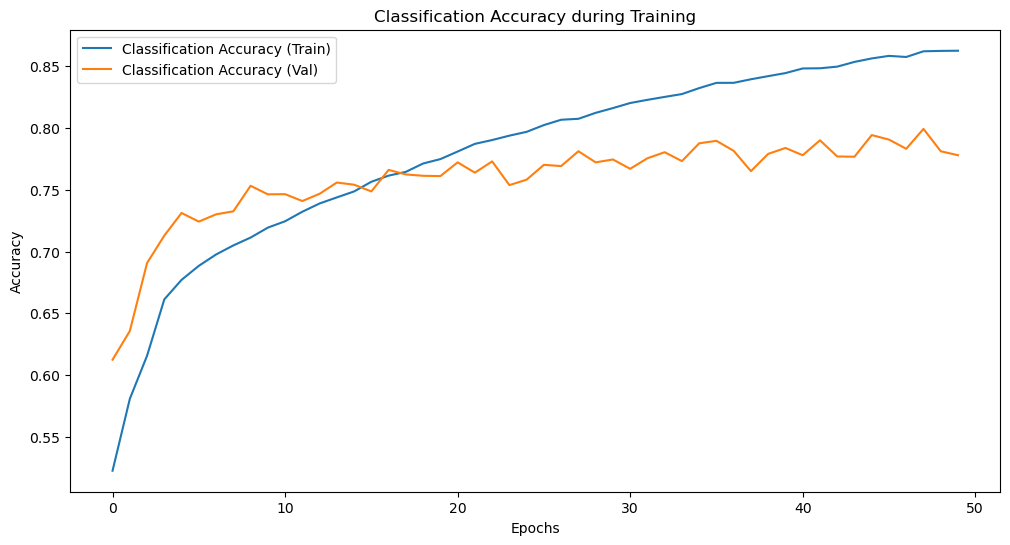

In [37]:
# Потери
plt.figure(figsize=(12, 6))
plt.plot(history.history['reconstructed_output_loss'], label='Reconstruction Loss (Train)')
plt.plot(history.history['val_reconstructed_output_loss'], label='Reconstruction Loss (Val)')
plt.plot(history.history['class_output_loss'], label='Classification Loss (Train)')
plt.plot(history.history['val_class_output_loss'], label='Classification Loss (Val)')
plt.title('Loss during Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Точность классификации
plt.figure(figsize=(12, 6))
plt.plot(history.history['class_output_accuracy'], label='Classification Accuracy (Train)')
plt.plot(history.history['val_class_output_accuracy'], label='Classification Accuracy (Val)')
plt.title('Classification Accuracy during Training')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
----------------------
#Тестирование на ноябре
----------------------

In [54]:
X_new=df_tail.drop(columns=["timestamp","imp_class"])
X_new=scaler.transform(X_new)
y_new = df_tail["imp_class"]

In [55]:
# Предсказание классов и реконструированных данных
predictions = autoencoder_classifier.predict(X_new)

# Классы
predicted_classes = np.argmax(predictions[1], axis=1)
predicted_classes_original = label_encoder.inverse_transform(predicted_classes)
# Реконструированные данные
reconstructed_data = predictions[0]

# Вывод
print("Original classes:", y_new.values)

print("Предсказанные классы:", predicted_classes_original)

print("Реконструированные данные:", reconstructed_data[:1])  # Первые 5 примеров

23/23 [==============================] - 0s 2ms/step
Original classes: [-1 -1 -1 -1 -1 -1 -1 -1 -2  0  0  0  0  0  0  0 -1 -2  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0 -1 -2  0  0  0  0  0  0  0  0 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -2 -1 -1 -1 -1 -2 -1 -2  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1 -1 -1 -1 -1 -2  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  2  0  0  0  0  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  2  0  0  0  1  2  0  0  0  0  0  1  1  1  1  1  1  2  0  0  0  0
  0  0  0  0  0  1  2  0  0  0  0  0  0  0  0  0  1  1  2  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  2  1  1  1  1  1
  1  1  1  2  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  2  0  0  0  0  0  0  0  0  1  1  1  2  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  1  

In [56]:
df_orign_tail = df_orign[df_orign['timestamp']>='2024-11-01 00:00:00']

In [57]:
trade_start_up1 = df_orign_tail[['timestamp','close']][df_orign_tail['imp_class']==1]
trade_stop_up1 = df_orign_tail[['timestamp','close']][df_orign_tail['imp_class']==2]
trade_start_down1 = df_orign_tail[['timestamp','close']][df_orign_tail['imp_class']==-1]
trade_stop_down1 = df_orign_tail[['timestamp','close']][df_orign_tail['imp_class']==-2]
trade_3 = df_orign_tail[['timestamp','close']][df_orign_tail['imp_class']==3]
trade_m3 = df_orign_tail[['timestamp','close']][df_orign_tail['imp_class']==-3]

df_p =pd.DataFrame();
df_p['timestamp']=df_tail['timestamp']
df_p['close'] =df_tail['close']
df_p['imp_class'] = predicted_classes_original

trade_start_up1_p = df_p[['timestamp','close']][df_p['imp_class']==1]
trade_stop_up1_p = df_p[['timestamp','close']][df_p['imp_class']==2]
trade_start_down1_p = df_p[['timestamp','close']][df_p['imp_class']==-1]
trade_stop_down1_p = df_p[['timestamp','close']][df_p['imp_class']==-2]

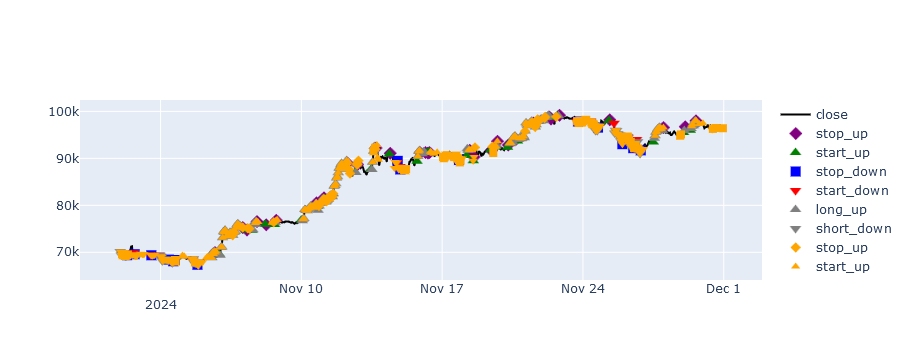

In [58]:
fig = make_subplots(rows=1, cols=1)
fig.add_trace(go.Scatter(x=df_orign_tail.timestamp, y=df_orign_tail.close, name='close',line_color = 'black', line_width=2 ))
fig.add_trace(go.Scatter(x=trade_stop_up1.timestamp, y=trade_stop_up1.close, name='stop_up',line_color = 'purple', line_width=1, mode='markers', marker_size = 10, marker_symbol = 2 ))
fig.add_trace(go.Scatter(x=trade_start_up1.timestamp, y=trade_start_up1.close, name='start_up',line_color = 'green', line_width=1, mode='markers', marker_size = 10, marker_symbol = 5 ))
fig.add_trace(go.Scatter(x=trade_stop_down1.timestamp, y=trade_stop_down1.close, name='stop_down',line_color = 'blue', line_width=1, mode='markers', marker_size = 10, marker_symbol = 1 ))
fig.add_trace(go.Scatter(x=trade_start_down1.timestamp, y=trade_start_down1.close, name='start_down',line_color = 'red', line_width=1, mode='markers', marker_size = 10, marker_symbol = 6 ))
[]
fig.add_trace(go.Scatter(x=trade_3.timestamp, y=trade_3.close, name='long_up',line_color = 'gray', line_width=1, mode='markers', marker_size = 10, marker_symbol = 5 ))
fig.add_trace(go.Scatter(x=trade_m3.timestamp, y=trade_m3.close, name='short_down',line_color = 'gray', line_width=1, mode='markers', marker_size = 10, marker_symbol = 6))

#fig.add_trace(go.Scatter(x=df_orign_tail.timestamp, y=df_orign_tail.close, name='close',line_color = 'black', line_width=2 ))
fig.add_trace(go.Scatter(x=trade_stop_up1_p.timestamp, y=trade_stop_up1_p.close, name='stop_up',line_color = 'orange', line_width=1, mode='markers', marker_size = 8, marker_symbol = 2 ))
fig.add_trace(go.Scatter(x=trade_start_up1_p.timestamp, y=trade_start_up1_p.close, name='start_up',line_color = 'orange', line_width=1, mode='markers', marker_size = 8, marker_symbol = 5 ))
fig.add_trace(go.Scatter(x=trade_stop_down1_p.timestamp, y=trade_stop_down1_p.close, name='stop_down',line_color = 'orange', line_width=1, mode='markers', marker_size = 8, marker_symbol = 1 ))
fig.add_trace(go.Scatter(x=trade_start_down1_p.timestamp, y=trade_start_down1_p.close, name='start_down',line_color = 'orange', line_width=1, mode='markers', marker_size = 8, marker_symbol = 6 ))
[]
#fig.add_trace(go.Scatter(x=trade_3.timestamp, y=trade_3.close, name='long_up',line_color = 'gray', line_width=1, mode='markers', marker_size = 10, marker_symbol = 5 ))
#fig.add_trace(go.Scatter(x=trade_m3.timestamp, y=trade_m3.close, name='short_down',line_color = 'gray', line_width=1, mode='markers', marker_size = 10, marker_symbol = 6))
fig.write_html(f"BTC_november_1h.html")
fig.update_layout(hovermode="x", title = "Цена и начало/конец импульса")